# Political Bias Evaluation Pipeline (Staged)

This notebook restructures political-bias analysis into explicit stages so we can see **how each stage changes totals** across all videos.

## Objective
Evaluate all videos for political bias while keeping a cumulative tally at each stage:

1. Baseline (all unknown)
2. Topic coverage
3. Lexicon-only framing
4. Lexicon + tags
5. Lexicon + tags + guest signal
6. Final resolved label and confidence
7. Unknown queue for manual review

The notebook uses the existing classified output as source-of-truth for signals and then rebuilds stage transitions for auditability.


## 0 - Setup and data contracts


In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


def find_project_root(marker="data/TRIGGERnometry-video-taxonomy/trigggerpod-classified.csv"):
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate project root containing "
        f"{marker}. Run notebook from inside the statistics-notes repo."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data/TRIGGERnometry-video-taxonomy"
CLASSIFIED_PATH = DATA_DIR / "trigggerpod-classified.csv"
UNKNOWN_REVIEW_PATH = DATA_DIR / "unknowns-review.csv"

required_columns = [
    "published_date", "title", "topics", "framing_score", "framing_label",
    "tags_framing_score", "guest_name_detected", "guest_signal",
    "combined_score", "combined_label", "signal_sources", "confidence",
]

df = pd.read_csv(CLASSIFIED_PATH, parse_dates=["published_date"])
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

for c in ["framing_score", "tags_framing_score", "guest_signal", "combined_score"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

if "topics" in df.columns:
    df["n_topics"] = df["topics"].fillna("").apply(lambda x: 0 if x == "" else len(str(x).split("|")))
else:
    df["n_topics"] = 0

print(f"Project root: {PROJECT_ROOT}")
print(f"Rows: {len(df):,}")
print(f"Date range: {df['published_date'].min().date()} -> {df['published_date'].max().date()}")
print(f"Columns checked: {len(required_columns)}")
print(f"No-topic videos: {(df['n_topics'] == 0).sum():,}")


Project root: /Users/nathanormond/Dev/playground/statistics-notes
Rows: 1,849
Date range: 2018-04-23 -> 2026-03-01
Columns checked: 12
No-topic videos: 601


## 1 - Stage engine (cumulative totals + deltas)

`record_stage()` captures counts, percentages, and deltas at each stage.


In [22]:
LABEL_ORDER = ["right-leaning", "left-leaning", "contested", "neutral", "unknown"]
stage_records = []


def normalize_label(s):
    s = s.fillna("unknown").astype(str)
    s = s.where(s.isin(LABEL_ORDER), "unknown")
    return s


def record_stage(stage_name, label_series, note=""):
    labels = normalize_label(label_series)
    counts = labels.value_counts().reindex(LABEL_ORDER, fill_value=0)
    total = int(counts.sum())

    row = {
        "stage": stage_name,
        "total": total,
        "note": note,
    }
    for label in LABEL_ORDER:
        row[f"{label}_count"] = int(counts[label])
        row[f"{label}_pct"] = float(counts[label] / total * 100.0 if total else 0.0)

    if stage_records:
        prev = stage_records[-1]
        for label in LABEL_ORDER:
            row[f"delta_{label}"] = row[f"{label}_count"] - prev[f"{label}_count"]
    else:
        for label in LABEL_ORDER:
            row[f"delta_{label}"] = 0

    stage_records.append(row)


def stage_summary_df():
    return pd.DataFrame(stage_records)


def classify_from_score(score, threshold=0.5):
    if score >= threshold:
        return "right-leaning"
    if score <= -threshold:
        return "left-leaning"
    return "unknown"


## 2 - Stage definitions and cumulative tracking


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPANDED GUEST IDENTITY DICTIONARY (synced with 04-guest-interview-bias.ipynb)
# ══════════════════════════════════════════════════════════════════════════════
# (category, wing, prominence) - wing ∈ {"right", "left", "contested"}
GUEST_IDENTITY: dict[str, tuple[str, str, int]] = {
    # UK Politicians
    "Kemi Badenoch": ("Conservative", "right", 5),
    "Liz Truss": ("Conservative, libertarian right", "right", 5),
    "Nigel Farage": ("Reform UK", "right", 5),
    "Robert Jenrick": ("Reform UK", "right", 3),
    "Suella Braverman": ("Conservative", "right", 4),
    "Jacob Rees-Mogg": ("Conservative", "right", 4),
    "Claire Fox": ("Brexit Party", "right", 3),
    "Laila Cunningham": ("Reform UK", "right", 2),
    "Mahyar Tousi": ("Reform UK", "right", 2),
    # UK Right-Wing Media
    "Douglas Murray": ("Right-wing commentator", "right", 4),
    "Peter Hitchens": ("Right-wing commentator", "right", 3),
    "Andrew Doyle": ("Right-wing commentator", "right", 3),
    "Toby Young": ("Right-wing commentator", "right", 3),
    "Melanie Phillips": ("Right-wing commentator", "right", 3),
    "David Starkey": ("Right-wing commentator", "right", 3),
    "Matt Goodwin": ("Reform UK (unsuccessful candidate)", "right", 2),
    "Matthew Goodwin": ("Reform UK (unsuccessful candidate)", "right", 2),
    "Mike Graham": ("Right-wing commentator", "right", 3),
    "Patrick Christys": ("Right-wing commentator", "right", 3),
    "Julia Hartley-Brewer": ("Right-wing commentator", "right", 3),
    "Isabel Oakeshott": ("Right-wing commentator", "right", 3),
    "Dan Wootton": ("Right-wing commentator", "right", 3),
    "Fraser Nelson": ("Right-wing commentator", "right", 3),
    "Brendan O'Neill": ("Right-wing commentator", "right", 3),
    "Iain Dale": ("Conservative", "right", 2),
    "Geoff Norcott": ("Conservative", "right", 2),
    "Tom Slater": ("Right-wing commentator", "right", 2),
    "Simon Evans": ("Right-wing commentator", "right", 2),
    "Dominic Frisby": ("Right-wing commentator", "right", 2),
    "Robin Aitken": ("Right-wing commentator", "right", 2),
    # Gender Critical
    "Katharine Birbalsingh": ("Right-wing commentator", "right", 3),
    "Helen Joyce": ("Gender critical", "right", 3),
    "Kathleen Stock": ("Gender critical", "right", 3),
    "Maya Forstater": ("Gender critical", "right", 2),
    "Posie Parker": ("Gender critical", "right", 2),
    "Sharron Davies": ("Gender critical", "right", 2),
    "Graham Linehan": ("Gender critical", "right", 2),
    "Debbie Hayton": ("Gender critical", "right", 2),
    # UK Far-Right
    "Tommy Robinson": ("Far-right activist", "right", 3),
    "Laurence Fox": ("Right-wing commentator", "right", 3),
    "Count Dankula": ("Right-wing commentator", "right", 2),
    # US Right-Wing
    "Jordan Peterson": ("Right-wing commentator", "right", 5),
    "Ben Shapiro": ("Right-wing commentator", "right", 5),
    "Tucker Carlson": ("Right-wing commentator", "right", 5),
    "Joe Rogan": ("Right-wing commentator", "right", 5),
    "Tim Pool": ("Right-wing commentator", "right", 4),
    "Candace Owens": ("Right-wing commentator", "right", 4),
    "Dave Rubin": ("Right-wing commentator", "right", 3),
    "Michael Malice": ("Right-wing commentator", "right", 3),
    "Adam Carolla": ("Right-wing commentator", "right", 3),
    "Greg Gutfeld": ("Right-wing commentator", "right", 3),
    "Ann Coulter": ("Right-wing commentator", "right", 3),
    "Jeremy Boreing": ("Right-wing commentator", "right", 3),
    "Andrew Klavan": ("Right-wing commentator", "right", 3),
    "James Lindsay": ("Right-wing commentator", "right", 3),
    "Dinesh D'Souza": ("Right-wing commentator", "right", 3),
    "Charlie Kirk": ("Right-wing commentator", "right", 3),
    "Nick Freitas": ("Republican", "right", 3),
    "Roseanne Barr": ("Right-wing commentator", "right", 3),
    "Dana White": ("Right-wing commentator", "right", 3),
    "Russell Brand": ("Right-wing commentator", "right", 4),
    # COVID Skeptics
    "Robert Malone": ("COVID skeptic", "right", 3),
    "Pierre Kory": ("COVID skeptic", "right", 2),
    "Peter McCullough": ("COVID skeptic", "right", 3),
    "Aseem Malhotra": ("COVID skeptic", "right", 3),
    "Jay Bhattacharya": ("COVID skeptic", "right", 3),
    "Sunetra Gupta": ("COVID skeptic", "right", 3),
    "Alex Berenson": ("COVID skeptic", "right", 3),
    "Naomi Wolf": ("COVID skeptic", "right", 3),
    "Dr John Campbell": ("COVID skeptic", "right", 3),
    "John Campbell": ("COVID skeptic", "right", 3),
    "Prof Karol Sikora": ("COVID skeptic", "right", 2),
    "Karol Sikora": ("COVID skeptic", "right", 2),
    # IDW
    "Eric Weinstein": ("IDW", "right", 3),
    "Bret Weinstein": ("IDW", "right", 3),
    "Peter Boghossian": ("IDW", "right", 2),
    # Right-leaning Academics
    "Niall Ferguson": ("Right-wing academic", "right", 4),
    "Sir Niall Ferguson": ("Right-wing academic", "right", 4),
    "Eric Kaufmann": ("Right-wing academic", "right", 3),
    "Dominic Sandbrook": ("Right-wing academic", "right", 3),
    "Matt Ridley": ("Right-wing academic", "right", 3),
    # Islam Critics
    "Raymond Ibrahim": ("Islam critic", "right", 2),
    "Maryam Namazie": ("Islam critic", "right", 2),
    "John Spencer": ("Pro-Israel analyst", "right", 2),
    # Anti-woke
    "Critical Drinker": ("Anti-woke commentator", "right", 3),
    "The Critical Drinker": ("Anti-woke commentator", "right", 3),
    "Zuby": ("Anti-woke commentator", "right", 2),
    "Lionel Shriver": ("Anti-woke commentator", "right", 3),
    "Mike Nayna": ("Anti-woke commentator", "right", 2),
    # Conservative Writers
    "Freya India": ("Conservative writer", "right", 2),
    "Louise Perry": ("Conservative writer", "right", 2),
    "Helen Andrews": ("Conservative writer", "right", 2),
    "Batya Ungar-Sargon": ("Conservative writer", "right", 3),
    # Left-wing
    "Aaron Bastani": ("Left-wing commentator", "left", 3),
    "Ash Sarkar": ("Left-wing commentator", "left", 3),
    "Owen Jones": ("Left-wing commentator", "left", 3),
    "Hasan Piker": ("Left-wing commentator", "left", 4),
    # Contested
    "Sam Harris": ("Heterodox", "contested", 3),
    "Glenn Greenwald": ("Heterodox", "contested", 3),
    "Jimmy Carr": ("Comedian", "right", 3),
    # ── Additional right-wing guests (user identified) ───────────────────
    "Nick Fuentes": ("White nationalist", "right", 4),
    "Brandon Tatum": ("Conservative commentator", "right", 3),
    "Officer Tatum": ("Conservative commentator", "right", 3),
    "Allister Heath": ("Conservative journalist", "right", 3),
    "Naftali Bennett": ("Israeli PM", "right", 5),
    "Benjamin Netanyahu": ("Israeli PM", "right", 5),
    "Erik Prince": ("Trump ally", "right", 4),
    "Tony Abbott": ("Conservative politician", "right", 5),
    "Wilfred Reilly": ("Conservative academic", "right", 3),
    "BJ Dichter": ("Freedom Convoy", "right", 3),
    "Andrew Gold": ("Right-wing podcaster", "right", 3),
    "Kelsi Sheren": ("Conservative commentator", "right", 3),
    "Rob Hersov": ("Conservative businessman", "right", 3),
    "Peter Bleksley": ("Ex-police detective", "right", 3),
    "Yossi Cohen": ("Ex-Mossad director", "right", 4),
    "Daniel Di Martino": ("Anti-socialist commentator", "right", 3),
    "Kathryn Porter": ("Anti-renewables analyst", "right", 3),
    "Stephen J. Shaw": ("Natalist documentarian", "right", 3),
    "Dr Paul Morland": ("Demographer", "right", 3),
    "Paul Morland": ("Demographer", "right", 3),
    "Jim Rickards": ("Economic doomist", "right", 3),
    "Konstantin Kisin": ("TRIGGERnometry host, contested", "contested", 4),
    # From unclassified-guests review
    "Colin Wright": ("Gender essentialist anti-trans", "right", 3),
    "Richard Dawkins": ("Transphobe", "right", 4),
    "Christopher Rufo": ("MAGA, CRT campaigner", "right", 4),
    "Stephen Fry": ("Centrist", "contested", 4),
    "Roger Hallam": ("XR/Just Stop Oil", "left", 3),
    "Combat Veteran Nick Freitas": ("Pro-Israel", "right", 3),
    "Nick Freitas": ("Pro-Israel", "right", 3),
    "Sharron Davies MBE": ("Gender-critical", "right", 3),
    "Dr Sebastian Gorka": ("Trump advisor", "right", 4),
    "Seb Gorka": ("Trump advisor", "right", 4),
    "John Spencer": ("Pro-Israel", "right", 3),
    "Michael Shellenberger": ("Twitter Files", "right", 3),
    "Pinchas Landau": ("Islamophobic framing", "right", 3),
    "Megyn Kelly": ("Conservative", "right", 4),
    "Matt Walsh": ("Anti-trans", "right", 4),
    "Andy Ngo": ("Antifa critic", "right", 3),
    "Victor Davis Hanson": ("Conservative", "right", 3),
    "Dennis Prager": ("PragerU", "right", 4),
    "Kevin Roberts": ("Project 2025", "right", 4),
    "Libs of TikTok": ("Anti-trans", "right", 4),
    "Natasha Hausdorff": ("Pro-Israel", "right", 3),
    "Dr Jay Bhattacharya": ("Lockdown skeptic", "right", 3),
    "Mike Benz": ("Deep state", "right", 3),
    "Pearl Davis": ("Nick Fuentes", "right", 3),
    "Dr David Starkey": ("Woke critic", "right", 3),
    "Neil Oliver": ("Nationalist", "right", 3),
    "Nigel Biggar": ("Colonialism", "right", 3),
    "Bruce Gilley": ("Colonialism", "right", 3),
    "Rob Schneider": ("Trump", "right", 3),
    "Bill Ackman": ("Trump", "right", 4),
    "Ariel Pink": ("Trump", "right", 3),
    "Lauren Southern": ("Far-right", "right", 4),
    "Peter Thiel": ("Right-wing tech", "right", 4),
    "Richard Hanania": ("Woke origins", "right", 3),
    "Abigail Shrier": ("Anti-trans", "right", 4),
    "Debra Soh": ("Gender essentialist", "right", 3),
    "Blaire White": ("Anti-trans", "right", 3),
    "Buck Angel": ("Anti-trans", "right", 3),
    "Jamie Reed": ("Trans whistleblower", "right", 3),
    "Heather Mac Donald": ("Universities", "right", 3),
    "Dan Crenshaw": ("Republican", "right", 4),
    "Dave Smith": ("Libertarian right", "right", 3),
    "Patrick Bet-David": ("Anti-establishment", "right", 3),
    "Kevin Sorbo": ("Conservative", "right", 3),
    "Viva Frei": ("Freedom Convoy", "right", 3),
    "Yoram Hazony": ("Anti-wokeness", "right", 3),
    "Gad Saad": ("Anti-woke", "right", 3),
    "Benjamin Boyce": ("Anti-woke critic, Evergreen", "contested", 3),

    # ── From unknowns-review.md manual classification ────────────────────
    "Tulsi Gabbard":        ("MAGA / Trump admin DNI", "right", 5),
    "Allison Pearson":      ("Conservative journalist", "right", 3),
    "Declan Ganley":        ("EU-skeptic businessman", "right", 3),
    "Lois McLatchie Miller": ("Conservative Christian legal", "right", 2),
    "Dr Pippa Malmgren":    ("Bush White House economist", "right", 3),
    "Pippa Malmgren":       ("Bush White House economist", "right", 3),
    "Presidential Advisor Dr Pippa Malmgren": ("Bush White House economist", "right", 3),
    "Jason Calacanis":      ("Right-libertarian tech investor", "right", 3),
    "Piers Morgan":         ("Center-right broadcaster", "right", 3),
    "James Whale":          ("Right-wing UK broadcaster", "right", 2),
    "Ed Husain":            ("Center-right Islam critic", "right", 3),
    "Elica Le Bon":         ("Anti-Iran regime activist", "right", 2),
    "Leo Kearse":           ("Right-leaning comedian", "right", 2),
    "Alan Dershowitz":      ("Pro-Trump legal commentator", "right", 3),
    "Andrew Bustamante":    ("Ex-CIA, right-leaning media", "right", 2),
    "Kehinde Andrews":      ("Left-wing academic", "left", 3),
    "Bassem Youssef":       ("Left-leaning satirist", "left", 3),
    "Scott Galloway":       ("Pragmatic liberal, moderate Democrat; anti-woke on masculinity/culture", "contested", 3),
    "Duncan Trussell":      ("Left-libertarian comedian", "left", 2),
    "Charlamagne tha God":  ("Center-left radio host", "left", 3),
    "Destiny":              ("Center-left political streamer", "left", 3),
    "Steven Bonnell":       ("Center-left political streamer", "left", 3),
    "Rory Stewart":         ("Former Conservative, anti-populist", "contested", 4),
    "Matthew Syed":         ("Centrist journalist", "contested", 3),
    # ── Politically unaffiliated / neutral ───────────────────────────────
    "Helen Pluckrose":      ("Anti-woke, Grievance Studies hoax", "right", 3),
    "Alex O'Connor":        ("Politically unaffiliated, neutral", "contested", 2),
    "Bill Maher": ("Liberal, anti-woke, COVID skeptic", "contested", 5),
}

# Optional style metadata: conspiratorial | heterodox | revolutionary | resentment
GUEST_STYLE: dict[str, str] = {
    "Mike Benz": "conspiratorial",
    "Michael Shellenberger": "conspiratorial",
    "Dr Jay Bhattacharya": "conspiratorial",
    "Sam Harris": "heterodox",
    "Glenn Greenwald": "heterodox",
    "Benjamin Boyce": "heterodox",
    "Bill Maher": "heterodox",
    "Stephen Fry": "heterodox",
    "Roger Hallam": "revolutionary",
    "Dave Smith": "resentment",
    "Gad Saad": "resentment",
    "Yoram Hazony": "resentment",
    "Patrick Bet-David": "resentment",
    "Rory Stewart": "heterodox",
    "Matthew Syed": "heterodox",
    "Scott Galloway": "heterodox",
}

def get_guest_style(guest_name):
    if pd.isna(guest_name) or guest_name == "":
        return ""
    style = GUEST_STYLE.get(guest_name)
    if style:
        return style
    for k in sorted(GUEST_STYLE.keys(), key=len, reverse=True):
        if isinstance(guest_name, str) and k in guest_name:
            return GUEST_STYLE[k]
    return ""

def get_identity_signal(guest_name):
    """Return identity-based signal: +1 for right, -1 for left, 0 otherwise."""
    if pd.isna(guest_name) or guest_name == "":
        return 0.0
    info = GUEST_IDENTITY.get(guest_name)
    if info is None:
        # Substring match: e.g. "Konstantin Kisin Holberg Debate Speech" -> "Konstantin Kisin"
        for k in sorted(GUEST_IDENTITY.keys(), key=len, reverse=True):
            if k in guest_name:
                info = GUEST_IDENTITY.get(k)
                break
    if info is None:
        return 0.0
    wing = info[1]
    if wing == "right":
        return 1.0
    elif wing == "left":
        return -1.0
    return 0.0

# ══════════════════════════════════════════════════════════════════════════════
# STAGE DEFINITIONS
# ══════════════════════════════════════════════════════════════════════════════

# Stage 0: Baseline - everything unknown
label_stage0 = pd.Series(["unknown"] * len(df), index=df.index)
record_stage("stage0_baseline", label_stage0, "All rows start unknown before any signal")

# Stage 1: Topic coverage gate (still unknown for bias labels, but coverage tracked)
label_stage1 = label_stage0.copy()
record_stage("stage1_topic_coverage", label_stage1, "Topic presence measured; no directional label yet")

# Stage 2: Lexicon-only framing (remove tags to isolate text lexicon impact)
lexicon_only_score = df["framing_score"] - df["tags_framing_score"]
label_stage2 = lexicon_only_score.apply(classify_from_score)
record_stage("stage2_lexicon_only", label_stage2, "Directional labels from title/description lexicon only")

# Stage 3: Lexicon + tags
label_stage3 = normalize_label(df["framing_label"])
record_stage("stage3_lexicon_plus_tags", label_stage3, "Tags signal integrated")

# Stage 4: Add guest signal from talking points (existing)
score_stage4 = df["framing_score"] + df["guest_signal"]
label_stage4 = score_stage4.apply(classify_from_score)
record_stage("stage4_plus_guest_talkingpoints", label_stage4, "Guest talking-points signal added")

# Stage 4b: Add expanded guest identity signal (from GUEST_IDENTITY dictionary)
identity_signal = df["guest_name_detected"].apply(get_identity_signal)
df["identity_signal"] = identity_signal
n_identity_matches = (identity_signal != 0).sum()
score_stage4b = score_stage4 + identity_signal
label_stage4b = score_stage4b.apply(classify_from_score)
record_stage("stage4b_plus_guest_identity", label_stage4b, f"Guest identity signal added ({n_identity_matches} matches)")

# Stage 5: Final resolved label from full rules
label_stage5 = normalize_label(df["combined_label"])
record_stage("stage5_final_resolved", label_stage5, "Conflict/contested handling + final resolution")

summary = stage_summary_df()
summary


,stage,total,note,right-leaning_count,right-leaning_pct,left-leaning_count,left-leaning_pct,contested_count,contested_pct,neutral_count,neutral_pct,unknown_count,unknown_pct,delta_right-leaning,delta_left-leaning,delta_contested,delta_neutral,delta_unknown
0,stage0_baseline,1849,All rows start unknown before any signal,0,0.000000,0,0.000000,0,0.000000,0,0.00000,1849,100.000000,0,0,0,0,0
1,stage1_topic_coverage,1849,Topic presence measured; no directional label yet,0,0.000000,0,0.000000,0,0.000000,0,0.00000,1849,100.000000,0,0,0,0,0
2,stage2_lexicon_only,1849,Directional labels from title/description lexi...,492,26.608978,0,0.000000,0,0.000000,0,0.00000,1357,73.391022,492,0,0,0,-492
3,stage3_lexicon_plus_tags,1849,Tags signal integrated,706,38.182802,0,0.000000,4,0.216333,3,0.16225,1136,61.438615,214,0,4,3,-221
4,stage4_plus_guest_talkingpoints,1849,Guest talking-points signal added,937,50.676041,6,0.324500,0,0.000000,0,0.00000,906,48.999459,231,6,-4,-3,-230
5,stage4b_plus_guest_identity,1849,Guest identity signal added (402 matches),937,50.676041,8,0.432666,0,0.000000,0,0.00000,904,48.891293,0,2,0,0,-2
6,stage5_final_resolved,1849,Conflict/contested handling + final resolution,937,50.676041,6,0.324500,3,0.162250,0,0.00000,903,48.837209,0,-2,3,0,-1


In [24]:
# Add guest_style if not present (from 03 output or compute from GUEST_STYLE)
if "guest_style" not in df.columns:
    df["guest_style"] = df["guest_name_detected"].apply(get_guest_style)

# Add stage columns to df for downstream visuals
df["label_stage0"] = label_stage0
df["label_stage1"] = label_stage1
df["label_stage2"] = label_stage2
df["label_stage3"] = label_stage3
df["label_stage4"] = label_stage4
df["label_stage4b"] = label_stage4b
df["label_stage5"] = label_stage5

# Unknown reduction table
unknown_progress = summary[["stage", "unknown_count", "unknown_pct", "delta_unknown", "note"]].copy()
unknown_progress


,stage,unknown_count,unknown_pct,delta_unknown,note
0,stage0_baseline,1849,100.000000,0,All rows start unknown before any signal
1,stage1_topic_coverage,1849,100.000000,0,Topic presence measured; no directional label yet
2,stage2_lexicon_only,1357,73.391022,-492,Directional labels from title/description lexi...
3,stage3_lexicon_plus_tags,1136,61.438615,-221,Tags signal integrated
4,stage4_plus_guest_talkingpoints,906,48.999459,-230,Guest talking-points signal added
5,stage4b_plus_guest_identity,904,48.891293,-2,Guest identity signal added (402 matches)
6,stage5_final_resolved,903,48.837209,-1,Conflict/contested handling + final resolution


## 3 - Stage visuals: totals and unknown reduction


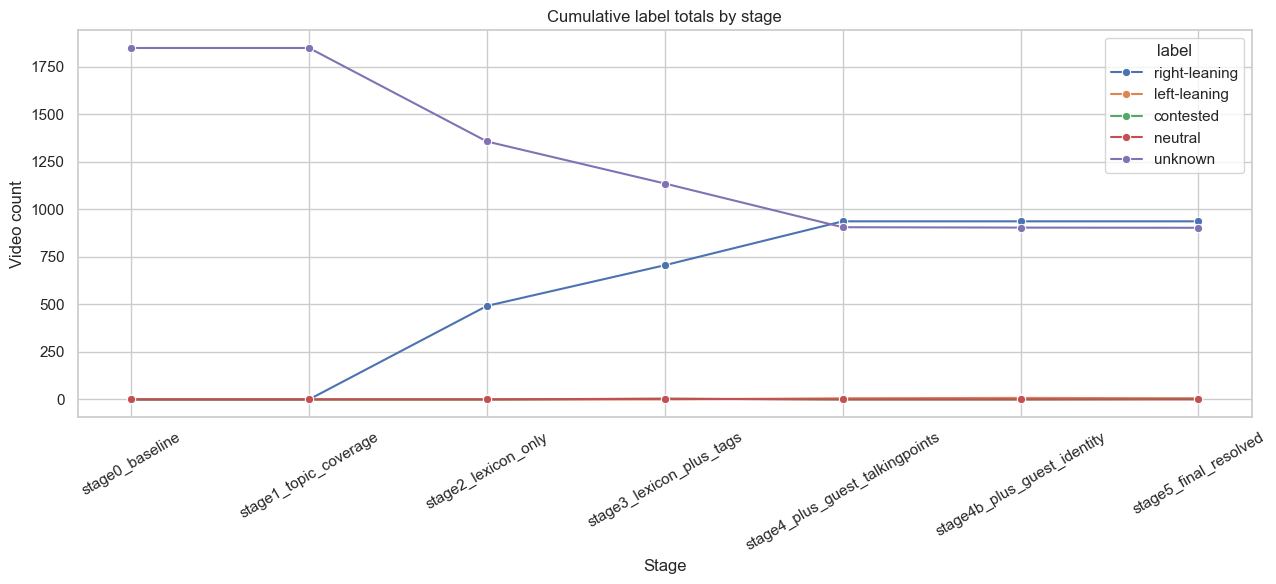

In [25]:
plot_df = summary[["stage"] + [f"{l}_count" for l in LABEL_ORDER]].copy()
long_df = plot_df.melt(id_vars="stage", var_name="label", value_name="count")
long_df["label"] = long_df["label"].str.replace("_count", "", regex=False)

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=long_df, x="stage", y="count", hue="label", marker="o", ax=ax)
ax.set_title("Cumulative label totals by stage")
ax.set_xlabel("Stage")
ax.set_ylabel("Video count")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


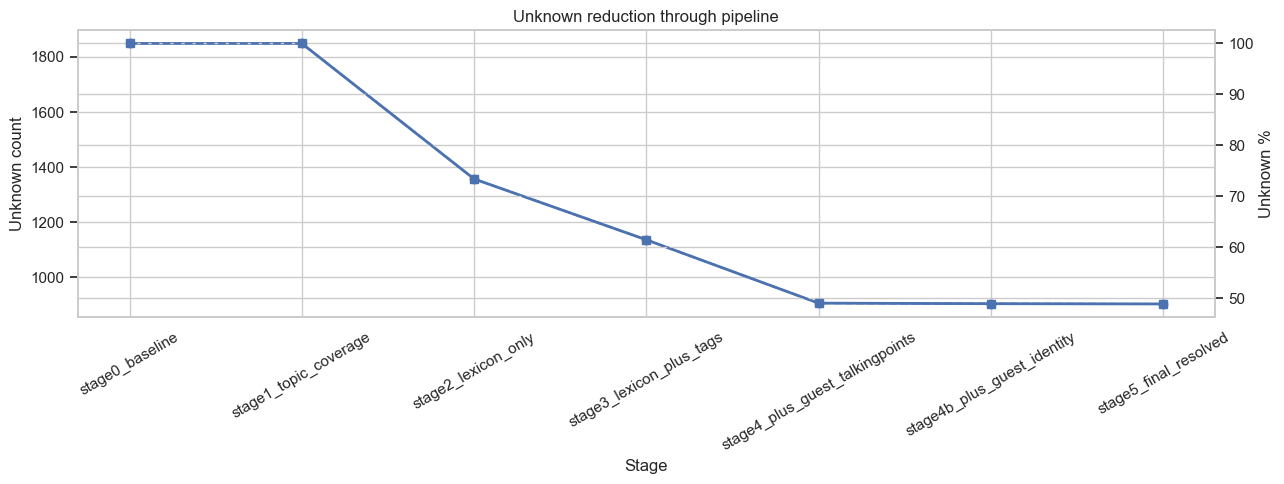

In [26]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(summary["stage"], summary["unknown_count"], marker="o", linewidth=2, label="Unknown count")
ax1.set_ylabel("Unknown count")
ax1.set_xlabel("Stage")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(summary["stage"], summary["unknown_pct"], marker="s", linestyle="--", label="Unknown %")
ax2.set_ylabel("Unknown %")

ax1.set_title("Unknown reduction through pipeline")
plt.tight_layout()
plt.show()


## 4 - Transition analysis: how labels move across stages


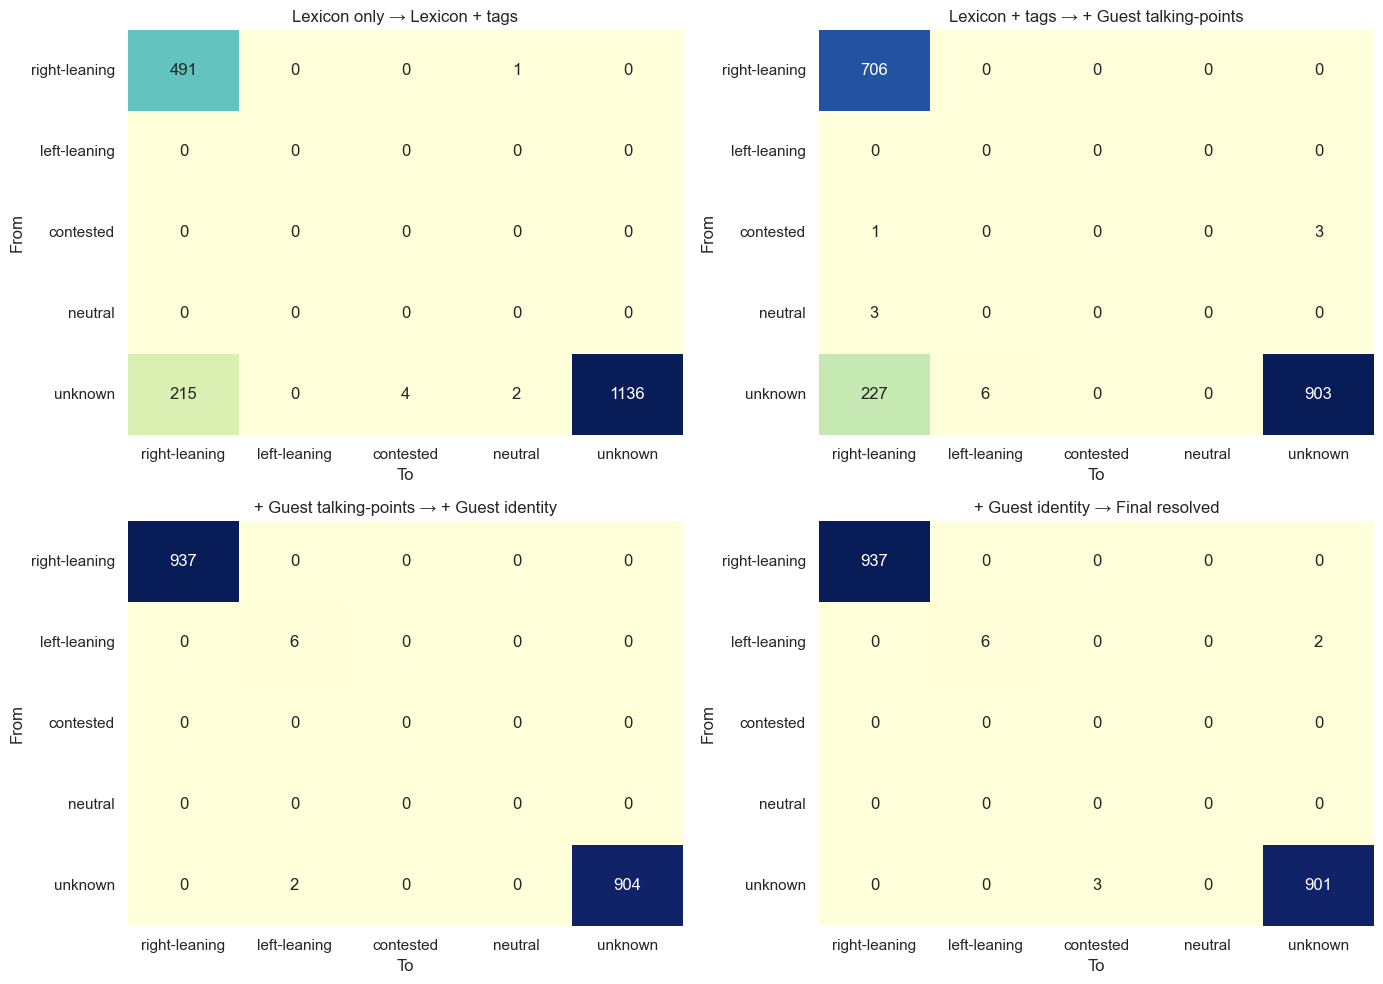

In [27]:
def transition_matrix(df, from_col, to_col):
    mat = pd.crosstab(df[from_col], df[to_col]).reindex(index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0)
    return mat

transitions = [
    ("label_stage2", "label_stage3", "Lexicon only → Lexicon + tags"),
    ("label_stage3", "label_stage4", "Lexicon + tags → + Guest talking-points"),
    ("label_stage4", "label_stage4b", "+ Guest talking-points → + Guest identity"),
    ("label_stage4b", "label_stage5", "+ Guest identity → Final resolved"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (src, dst, title) in zip(axes.flatten(), transitions):
    mat = transition_matrix(df, src, dst)
    sns.heatmap(mat, annot=True, fmt="d", cmap="YlGnBu", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("To")
    ax.set_ylabel("From")

plt.tight_layout()
plt.show()


## 5 - Signal contribution visuals


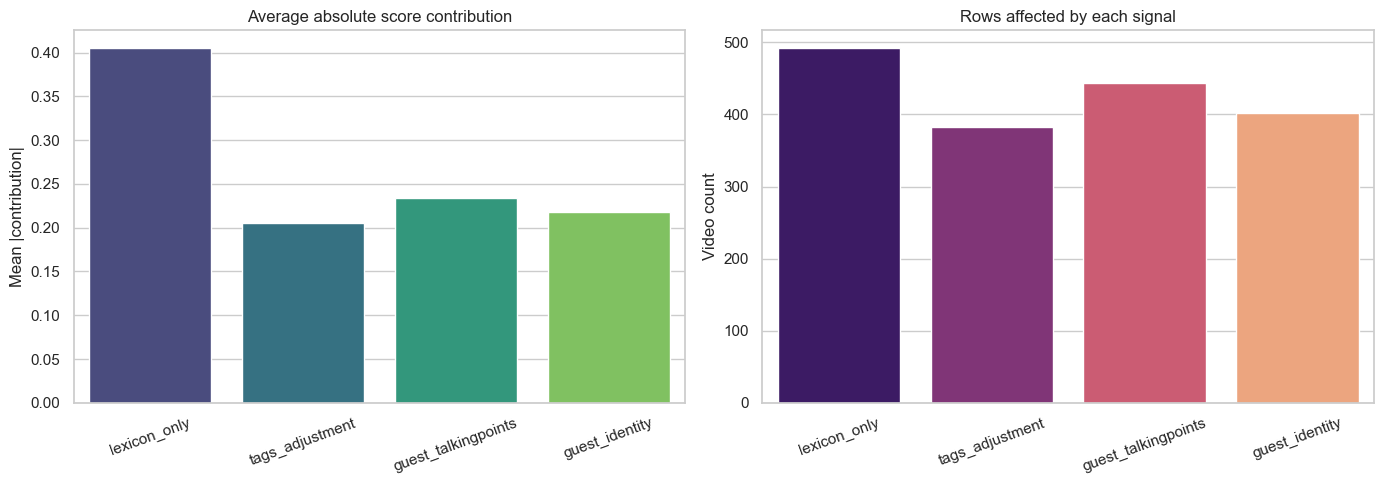

,component,mean_abs_contribution,nonzero_rows
0,lexicon_only,0.405084,492
1,tags_adjustment,0.204976,383
2,guest_talkingpoints,0.233775,444
3,guest_identity,0.217415,402


In [28]:
contrib = pd.DataFrame({
    "component": ["lexicon_only", "tags_adjustment", "guest_talkingpoints", "guest_identity"],
    "mean_abs_contribution": [
        (df["framing_score"] - df["tags_framing_score"]).abs().mean(),
        df["tags_framing_score"].abs().mean(),
        df["guest_signal"].abs().mean(),
        df["identity_signal"].abs().mean(),
    ],
    "nonzero_rows": [
        int(((df["framing_score"] - df["tags_framing_score"]) != 0).sum()),
        int((df["tags_framing_score"] != 0).sum()),
        int((df["guest_signal"] != 0).sum()),
        int((df["identity_signal"] != 0).sum()),
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=contrib, x="component", y="mean_abs_contribution", ax=axes[0], palette="viridis", hue="component", legend=False)
axes[0].set_title("Average absolute score contribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean |contribution|")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=contrib, x="component", y="nonzero_rows", ax=axes[1], palette="magma", hue="component", legend=False)
axes[1].set_title("Rows affected by each signal")
axes[1].set_xlabel("")
axes[1].set_ylabel("Video count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

contrib


## 6 - Yearly trend of final labels


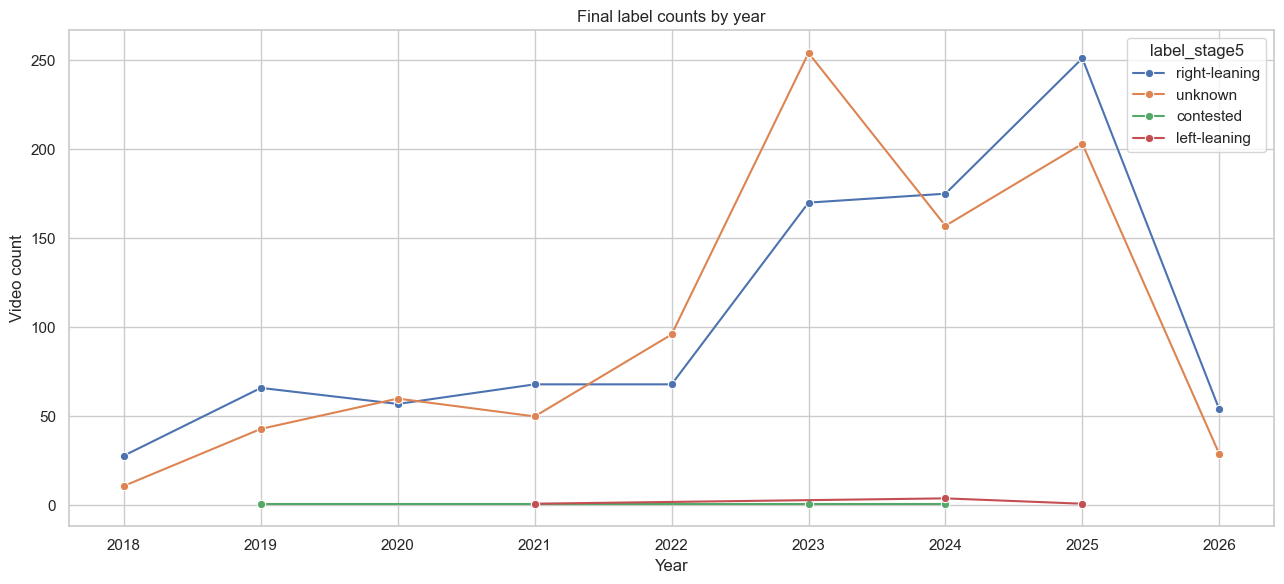

In [29]:
yearly = (
    df.assign(year=df["published_date"].dt.year)
      .groupby(["year", "label_stage5"])
      .size()
      .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(data=yearly, x="year", y="count", hue="label_stage5", marker="o", ax=ax)
ax.set_title("Final label counts by year")
ax.set_xlabel("Year")
ax.set_ylabel("Video count")
plt.tight_layout()
plt.show()


## 7 - Unknown review queue (persistent)

This surfaces unknowns for manual adjudication and keeps editable fields (`manual_label`, `manual_notes`).


In [30]:
if UNKNOWN_REVIEW_PATH.exists():
    unknown_review = pd.read_csv(UNKNOWN_REVIEW_PATH)
else:
    unknown_review = pd.DataFrame()

final_unknowns = df[df["label_stage5"] == "unknown"].copy()

print(f"Final unknown count: {len(final_unknowns):,}")
if not unknown_review.empty:
    print(f"Existing unknown review rows: {len(unknown_review):,}")

preview_cols = [c for c in [
    "published_date", "title", "guest_name_detected", "guest_signal",
    "signal_sources", "confidence", "combined_score"
] if c in final_unknowns.columns]

final_unknowns[preview_cols].head(25)


Final unknown count: 903
Existing unknown review rows: 903


,published_date,title,guest_name_detected,guest_signal,signal_sources,confidence,combined_score
0,2018-04-23,"Gideon Rachman on Trump, Russia, China, Israel...",Gideon Rachman,0.0,NaN,none,0.0
5,2018-05-21,David Pilling on the Growth Delusion and Good ...,David Pilling,0.0,NaN,none,0.0
6,2018-05-28,"Peter Tatchell on Human Rights, Free Speech an...",Peter Tatchell,0.0,NaN,none,0.0
9,2018-06-18,"Dr Linda Yueh on Inequality, China and the End...",Dr Linda Yueh,0.0,NaN,none,0.0
10,2018-06-24,"Jeremy Shapiro on Trump, Trident, Israel & Iran",Jeremy Shapiro,0.0,NaN,none,0.0
16,2018-08-06,"Scott Capurro on Comedy, Offence and Politics ...",Scott Capurro,0.0,NaN,none,0.0
19,2018-08-31,TRIGGERnometry Read Mean Tweets,NaN,0.0,NaN,none,0.0
26,2018-10-15,"Nicholas Gruen on Immigration, Corruption in A...",Nicholas Gruen,0.0,NaN,none,0.0
31,2018-11-18,"Chloe Westley on Tax, Brexit & Socialism",Chloe Westley,0.0,NaN,none,0.0
33,2018-12-03,News From TRIGGERnometry,NaN,0.0,NaN,none,0.0


## 9 - Manual label override merge

Load curated `manual_label` values from `unknowns-review.csv` and apply them as overrides to the final classification. Only non-empty, valid labels will override automated results.

In [31]:
VALID_MANUAL_LABELS = {"right-leaning", "left-leaning", "contested", "neutral", "unknown"}

if UNKNOWN_REVIEW_PATH.exists():
    manual_df = pd.read_csv(UNKNOWN_REVIEW_PATH)
    print(f"Loaded unknowns-review.csv: {len(manual_df):,} rows")
else:
    manual_df = pd.DataFrame()
    print("No unknowns-review.csv found; manual override stage will be skipped.")

if not manual_df.empty and "manual_label" in manual_df.columns:
    manual_df["manual_label_raw"] = manual_df["manual_label"].fillna("").astype(str).str.strip().str.lower()
    manual_df["manual_label_valid"] = manual_df["manual_label_raw"].where(
        manual_df["manual_label_raw"].isin(VALID_MANUAL_LABELS), ""
    )
    
    n_with_label = (manual_df["manual_label_valid"] != "").sum()
    n_invalid = ((manual_df["manual_label_raw"] != "") & (manual_df["manual_label_valid"] == "")).sum()
    
    print(f"Rows with valid manual_label: {n_with_label:,}")
    if n_invalid > 0:
        print(f"WARNING: {n_invalid:,} rows have invalid manual_label values (ignored)")
        invalid_examples = manual_df[
            (manual_df["manual_label_raw"] != "") & (manual_df["manual_label_valid"] == "")
        ]["manual_label_raw"].value_counts().head(5)
        print(f"  Invalid examples: {invalid_examples.to_dict()}")
else:
    manual_df["manual_label_valid"] = ""
    print("No manual_label column found or empty review file.")

Loaded unknowns-review.csv: 903 rows
Rows with valid manual_label: 0


In [32]:
def create_join_key(title, date):
    title_clean = str(title).strip().lower()
    date_str = str(date)[:10] if pd.notna(date) else ""
    return f"{title_clean}|{date_str}"

df["_join_key"] = df.apply(lambda r: create_join_key(r["title"], r["published_date"]), axis=1)

if not manual_df.empty and "title" in manual_df.columns:
    manual_df["_join_key"] = manual_df.apply(
        lambda r: create_join_key(r.get("title", ""), r.get("published_date", "")), axis=1
    )
    
    dup_keys = manual_df[manual_df["manual_label_valid"] != ""]["_join_key"].value_counts()
    dup_keys = dup_keys[dup_keys > 1]
    if len(dup_keys) > 0:
        print(f"WARNING: {len(dup_keys)} duplicate join keys in manual review (first label used)")
    
    manual_lookup = (
        manual_df[manual_df["manual_label_valid"] != ""]
        .drop_duplicates(subset="_join_key", keep="first")
        .set_index("_join_key")[["manual_label_valid"]]
    )
    if "manual_notes" in manual_df.columns:
        manual_lookup["manual_notes"] = (
            manual_df[manual_df["manual_label_valid"] != ""]
            .drop_duplicates(subset="_join_key", keep="first")
            .set_index("_join_key")["manual_notes"]
        )
    else:
        manual_lookup["manual_notes"] = ""
    
    df = df.join(manual_lookup, on="_join_key", how="left")
    df["manual_label_valid"] = df["manual_label_valid"].fillna("")
    df["manual_notes"] = df.get("manual_notes", pd.Series([""] * len(df))).fillna("")
else:
    df["manual_label_valid"] = ""
    df["manual_notes"] = ""

df["manual_override_applied"] = df["manual_label_valid"] != ""
df["combined_label_with_manual"] = df.apply(
    lambda r: r["manual_label_valid"] if r["manual_override_applied"] else r["label_stage5"],
    axis=1
)
df["manual_override_note"] = df["manual_notes"]

n_overrides = df["manual_override_applied"].sum()
print(f"\nManual overrides applied: {n_overrides:,}")
print(f"Unknown before manual: {(df['label_stage5'] == 'unknown').sum():,}")
print(f"Unknown after manual:  {(df['combined_label_with_manual'] == 'unknown').sum():,}")


Manual overrides applied: 0
Unknown before manual: 903
Unknown after manual:  903


In [33]:
label_stage6 = normalize_label(df["combined_label_with_manual"])
record_stage("stage6_manual_override", label_stage6, f"Manual overrides applied: {n_overrides:,}")

df["label_stage6"] = label_stage6

summary = stage_summary_df()
display(summary[["stage", "unknown_count", "unknown_pct", "delta_unknown", "note"]])

stage5_unknown = (df["label_stage5"] == "unknown").sum()
stage6_unknown = (df["label_stage6"] == "unknown").sum()
manual_unknown_reduction = stage5_unknown - stage6_unknown

print(f"\nStage 5 -> Stage 6 unknown reduction: {stage5_unknown:,} -> {stage6_unknown:,} ({manual_unknown_reduction:,} reclassified)")

if n_overrides > 0:
    print("\nTop manual overrides applied:")
    overridden = df[df["manual_override_applied"]][["title", "label_stage5", "combined_label_with_manual", "manual_override_note"]].head(10)
    overridden.columns = ["title", "before", "after", "note"]
    display(overridden)

,stage,unknown_count,unknown_pct,delta_unknown,note
0,stage0_baseline,1849,100.000000,0,All rows start unknown before any signal
1,stage1_topic_coverage,1849,100.000000,0,Topic presence measured; no directional label yet
2,stage2_lexicon_only,1357,73.391022,-492,Directional labels from title/description lexi...
3,stage3_lexicon_plus_tags,1136,61.438615,-221,Tags signal integrated
4,stage4_plus_guest_talkingpoints,906,48.999459,-230,Guest talking-points signal added
5,stage4b_plus_guest_identity,904,48.891293,-2,Guest identity signal added (402 matches)
6,stage5_final_resolved,903,48.837209,-1,Conflict/contested handling + final resolution
7,stage6_manual_override,903,48.837209,0,Manual overrides applied: 0



Stage 5 -> Stage 6 unknown reduction: 903 -> 903 (0 reclassified)


### Manual override impact visuals

In [34]:
if n_overrides > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    mat_manual = transition_matrix(df, "label_stage5", "label_stage6")
    sns.heatmap(mat_manual, annot=True, fmt="d", cmap="YlGnBu", cbar=False, ax=axes[0])
    axes[0].set_title("Transition: stage5 -> stage6 (with manual)")
    axes[0].set_xlabel("After manual override")
    axes[0].set_ylabel("Before (automated)")
    
    override_dist = df[df["manual_override_applied"]]["combined_label_with_manual"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    sns.barplot(
        x=override_dist.index,
        y=override_dist.values,
        ax=axes[1],
        hue=override_dist.index,
        palette="Set2",
        dodge=False,
        legend=False,
    )
    axes[1].set_title(f"Manual overrides by target label (n={n_overrides:,})")
    axes[1].set_xlabel("Target label")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=30)
    
    plt.tight_layout()
    plt.show()
else:
    print("No manual overrides to visualize.")

No manual overrides to visualize.


## 8 - Cumulative bias score (all signals, all videos)

A single numeric **cumulative bias score** for every video, decomposed into
its contributing components from all upstream analysis:

| Component | Source | Direction |
|---|---|---|
| Lexicon (title/description) | Notebook 03 | text keywords |
| Tag framing | Notebook 03 | YouTube tag keywords |
| Guest talking-points | Notebook 03 | guest × topic overlap |
| Guest identity | Notebook 05 | guest dictionary lookup |

Positive scores → right-leaning signal, negative → left-leaning.
Manual overrides (stage 6) adjust the **label** but not the numeric score.


In [35]:
# ── Cumulative bias score — all components ────────────────────────────

df["score_lexicon"]             = df["framing_score"] - df["tags_framing_score"]
df["score_tags"]                = df["tags_framing_score"]
df["score_guest_talkingpoints"] = df["guest_signal"]
df["score_guest_identity"]      = df["identity_signal"]

df["cumulative_bias_score"] = (
    df["score_lexicon"]
    + df["score_tags"]
    + df["score_guest_talkingpoints"]
    + df["score_guest_identity"]
)

df["final_label"] = df["label_stage6"]

# ── Bring in NB04 affiliation data if available ──────────────────────
INTERVIEWS_PATH = DATA_DIR / "trigggerpod-interviews.csv"
if INTERVIEWS_PATH.exists():
    nb04_df = pd.read_csv(INTERVIEWS_PATH, usecols=lambda c: c in [
        "title", "published_date", "party", "affiliation_wing", "prominence",
        "stance", "bias_category",
    ])
    nb04_df["_join_key"] = nb04_df.apply(
        lambda r: f"{str(r.get('title','')).strip().lower()}|{str(r.get('published_date',''))[:10]}",
        axis=1,
    )
    nb04_df = nb04_df.drop_duplicates(subset="_join_key", keep="first")
    # Merge NB04 columns
    for col in ["party", "affiliation_wing", "prominence", "stance", "bias_category"]:
        if col in nb04_df.columns and col not in df.columns:
            lookup = nb04_df.set_index("_join_key")[col]
            df[col] = df["_join_key"].map(lookup)
    n_with_aff = df["affiliation_wing"].notna().sum() if "affiliation_wing" in df.columns else 0
    print(f"NB04 enrichment: {n_with_aff:,} videos with party affiliation")
else:
    print(f"NB04 interviews CSV not found at {INTERVIEWS_PATH.name}; skipping enrichment")

# ── Summary ──────────────────────────────────────────────────────────
print(f"\nCumulative bias score computed for {len(df):,} videos")
print(f"  Score range:  {df['cumulative_bias_score'].min():.2f}  to  {df['cumulative_bias_score'].max():.2f}")
print(f"  Mean:         {df['cumulative_bias_score'].mean():.3f}")
print(f"  Median:       {df['cumulative_bias_score'].median():.3f}")
print(f"  Std dev:      {df['cumulative_bias_score'].std():.3f}")
print(f"  Zero scores:  {(df['cumulative_bias_score'] == 0).sum():,}")

# Component contribution (non-zero counts)
for comp in ["score_lexicon", "score_tags", "score_guest_talkingpoints", "score_guest_identity"]:
    nonzero = (df[comp] != 0).sum()
    print(f"  {comp:32s}: {nonzero:>5,} non-zero  (mean {df[comp].mean():+.3f})")


NB04 enrichment: 436 videos with party affiliation

Cumulative bias score computed for 1,849 videos
  Score range:  -2.00  to  10.50
  Mean:         1.042
  Median:       0.500
  Std dev:      1.428
  Zero scores:  904
  score_lexicon                   :   492 non-zero  (mean +0.405)
  score_tags                      :   383 non-zero  (mean +0.204)
  score_guest_talkingpoints       :   444 non-zero  (mean +0.226)
  score_guest_identity            :   402 non-zero  (mean +0.207)


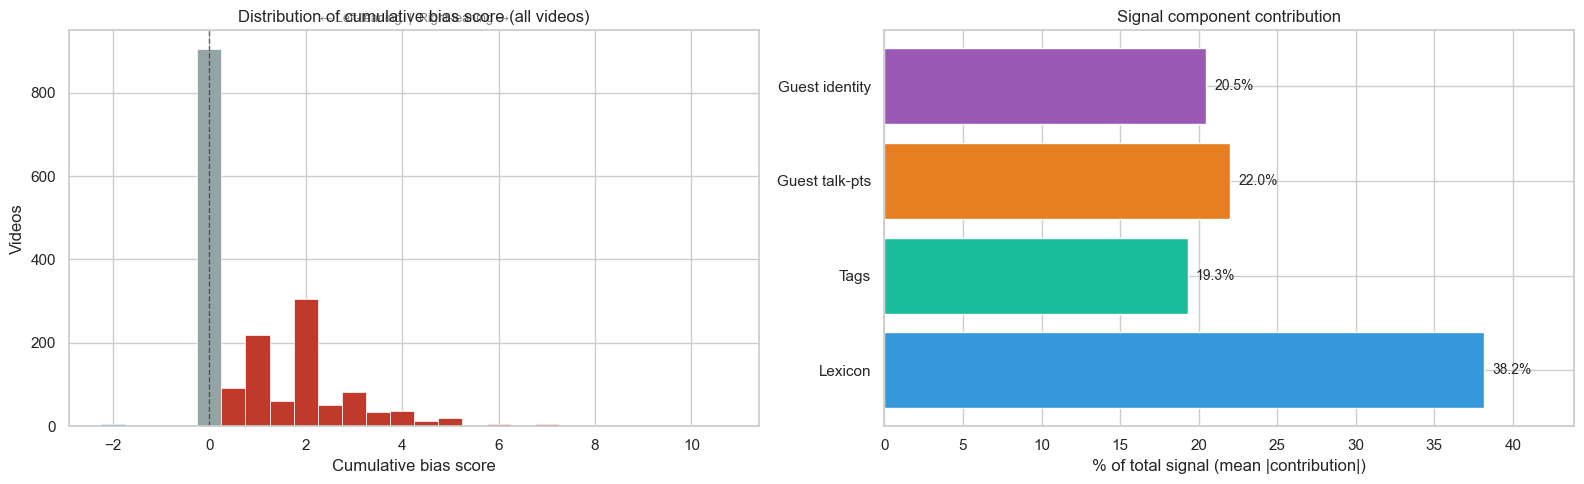

In [36]:
# ── Cumulative score distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wing_colors = {"right": "#c0392b", "left": "#2980b9", "contested": "#f39c12",
               "neutral": "#95a5a6", "unknown": "#d5d8dc"}

# 1. Histogram of cumulative score
ax = axes[0]
scores = df["cumulative_bias_score"]
bins = np.arange(scores.min() - 0.25, scores.max() + 0.75, 0.5)
n, bin_edges, patches = ax.hist(scores, bins=bins, edgecolor="white", linewidth=0.5, color="#7f8c8d")
# Colour bars: red for positive, blue for negative, grey for zero
for patch, left_edge in zip(patches, bin_edges):
    mid = left_edge + 0.25
    if mid > 0.25:
        patch.set_facecolor("#c0392b")
    elif mid < -0.25:
        patch.set_facecolor("#2980b9")
    else:
        patch.set_facecolor("#95a5a6")
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Cumulative bias score")
ax.set_ylabel("Videos")
ax.set_title("Distribution of cumulative bias score (all videos)")
ax.annotate(f"← Left-leaning  |  Right-leaning →", xy=(0.5, 1.02),
            xycoords="axes fraction", ha="center", fontsize=9, color="grey")

# 2. Stacked component contribution for non-zero-score videos
ax = axes[1]
components = ["score_lexicon", "score_tags", "score_guest_talkingpoints", "score_guest_identity"]
comp_labels = ["Lexicon", "Tags", "Guest talk-pts", "Guest identity"]
comp_colors = ["#3498db", "#1abc9c", "#e67e22", "#9b59b6"]

# Mean absolute contribution per component
mean_abs = [df[c].abs().mean() for c in components]
total_abs = sum(mean_abs)
if total_abs > 0:
    pcts = [m / total_abs * 100 for m in mean_abs]
else:
    pcts = [0] * len(components)

bars = ax.barh(comp_labels, pcts, color=comp_colors, edgecolor="white")
for bar, pct in zip(bars, pcts):
    if pct > 2:
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va="center", fontsize=10)
ax.set_xlabel("% of total signal (mean |contribution|)")
ax.set_title("Signal component contribution")
ax.set_xlim(0, max(pcts) * 1.15 if pcts else 100)

plt.tight_layout()
plt.show()


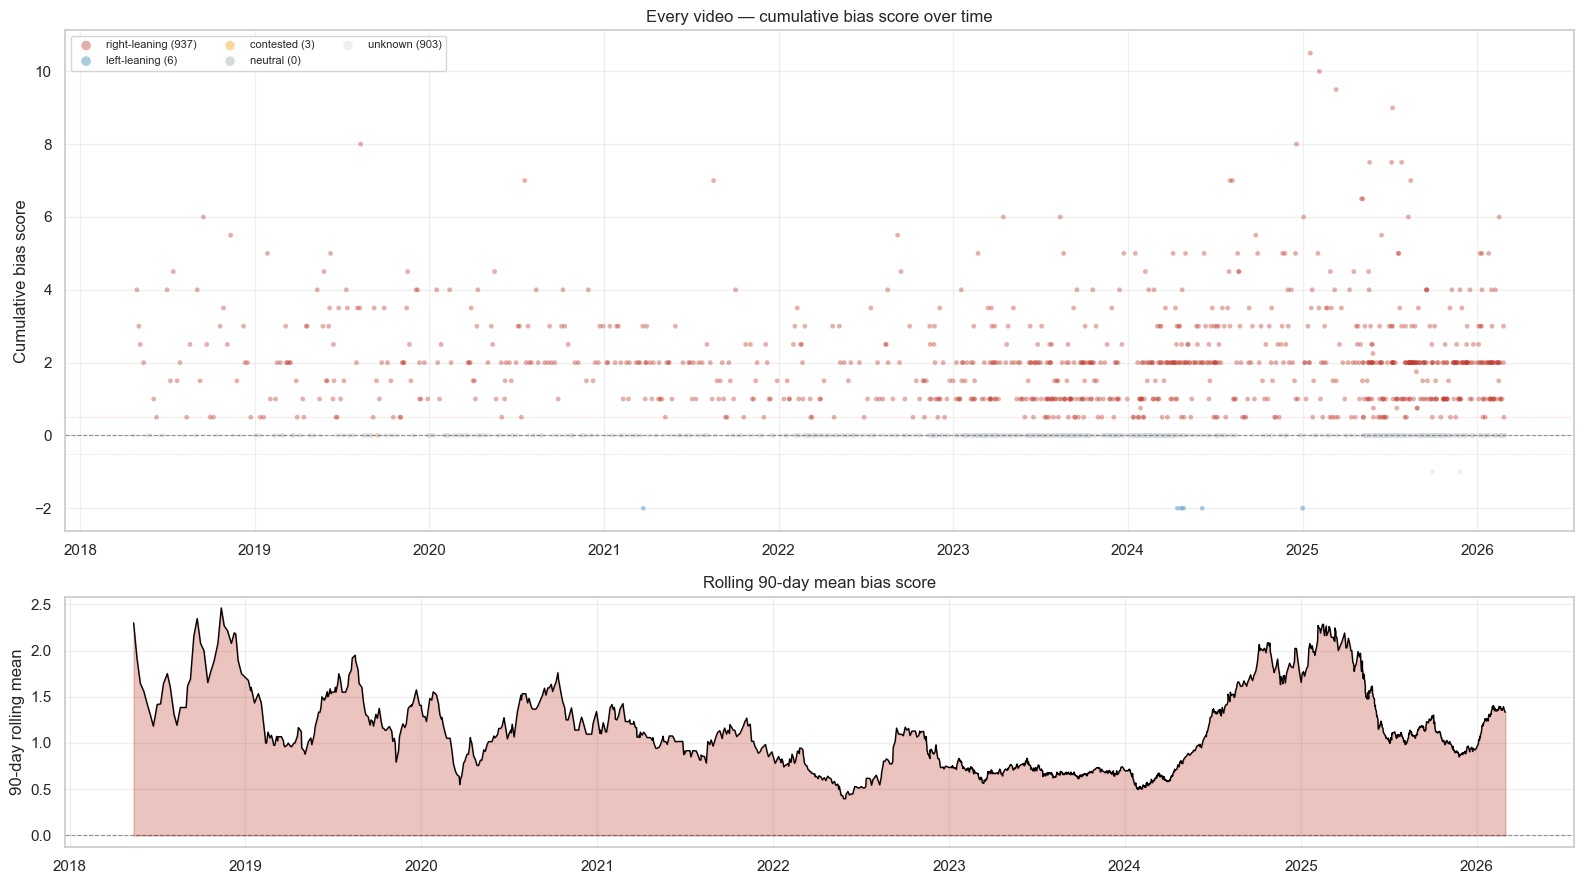

In [37]:
# ── Cumulative score over time ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={"height_ratios": [2, 1]})

# 1. Scatter: every video coloured by final label
ax = axes[0]
label_colors = {
    "right-leaning": "#c0392b", "left-leaning": "#2980b9",
    "contested": "#f39c12", "neutral": "#95a5a6", "unknown": "#d5d8dc",
}
for label in LABEL_ORDER:
    mask = df["final_label"] == label
    subset = df[mask]
    ax.scatter(
        subset["published_date"], subset["cumulative_bias_score"],
        c=label_colors[label], alpha=0.4, s=12, label=f"{label} ({mask.sum():,})",
        edgecolors="none",
    )
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.axhline(0.5, color="#c0392b", linewidth=0.6, linestyle=":", alpha=0.3)
ax.axhline(-0.5, color="#2980b9", linewidth=0.6, linestyle=":", alpha=0.3)
ax.set_ylabel("Cumulative bias score")
ax.set_title("Every video — cumulative bias score over time")
ax.legend(loc="upper left", fontsize=8, ncol=3, markerscale=2)
ax.grid(alpha=0.3)

# 2. Rolling 90-day mean score
ax = axes[1]
ts = df.set_index("published_date")["cumulative_bias_score"].sort_index()
rolling = ts.rolling(window="90D", min_periods=5).mean()
ax.fill_between(rolling.index, rolling.values, 0,
                where=rolling.values >= 0, color="#c0392b", alpha=0.3)
ax.fill_between(rolling.index, rolling.values, 0,
                where=rolling.values < 0, color="#2980b9", alpha=0.3)
ax.plot(rolling.index, rolling.values, color="black", linewidth=1)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_ylabel("90-day rolling mean")
ax.set_xlabel("")
ax.set_title("Rolling 90-day mean bias score")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


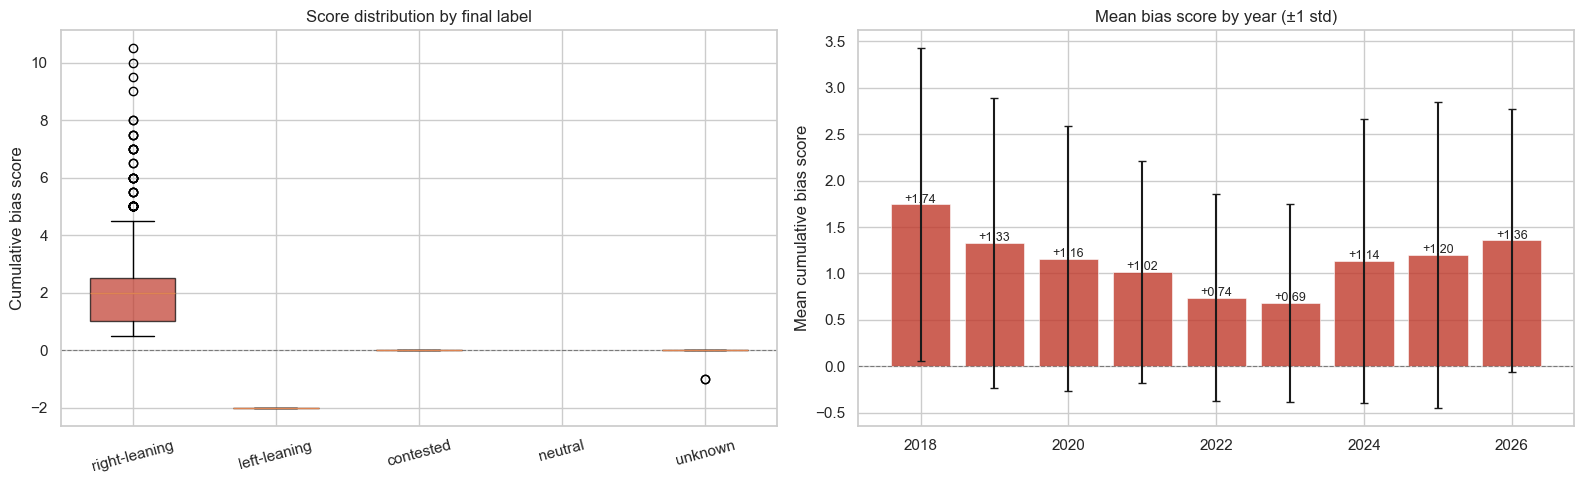

In [38]:
# ── Score distribution by final label ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Box plot: score by final label
ax = axes[0]
label_data = [df[df["final_label"] == l]["cumulative_bias_score"].values for l in LABEL_ORDER]
bp = ax.boxplot(label_data, tick_labels=LABEL_ORDER, vert=True, patch_artist=True, widths=0.6)
for patch, label in zip(bp["boxes"], LABEL_ORDER):
    patch.set_facecolor(label_colors.get(label, "grey"))
    patch.set_alpha(0.7)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_ylabel("Cumulative bias score")
ax.set_title("Score distribution by final label")
ax.tick_params(axis="x", rotation=15)

# 2. Yearly mean score with error bars
ax = axes[1]
yearly = df.assign(year=df["published_date"].dt.year).groupby("year")["cumulative_bias_score"]
yearly_mean = yearly.mean()
yearly_std = yearly.std()
years = yearly_mean.index

bars = ax.bar(years, yearly_mean.values, yerr=yearly_std.values,
              capsize=3, edgecolor="white", linewidth=0.5,
              color=[("#c0392b" if m > 0 else "#2980b9" if m < 0 else "#95a5a6")
                     for m in yearly_mean.values],
              alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.set_ylabel("Mean cumulative bias score")
ax.set_title("Mean bias score by year (±1 std)")
ax.set_xlabel("")
for bar, mean_val in zip(bars, yearly_mean.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{mean_val:+.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


In [39]:
# ── Comprehensive cumulative score summary ────────────────────────────

print("=" * 75)
print("CUMULATIVE BIAS SCORE — ALL VIDEOS SUMMARY")
print("=" * 75)

total = len(df)
final_counts = df["final_label"].value_counts().reindex(LABEL_ORDER, fill_value=0)

print(f"\nTotal videos:  {total:,}")
print(f"\nFinal label distribution:")
for label in LABEL_ORDER:
    cnt = final_counts[label]
    pct = cnt / total * 100
    mean_score = df[df["final_label"] == label]["cumulative_bias_score"].mean()
    print(f"  {label:15s}: {cnt:>5,}  ({pct:5.1f}%)  mean score: {mean_score:+.2f}")

# Score quintile breakdown
print(f"\nScore quintile breakdown:")
df["score_quintile"] = pd.qcut(df["cumulative_bias_score"], q=5, duplicates="drop")
for q, grp in df.groupby("score_quintile", observed=True):
    r = (grp["final_label"] == "right-leaning").sum()
    l = (grp["final_label"] == "left-leaning").sum()
    u = (grp["final_label"] == "unknown").sum()
    print(f"  {str(q):25s}:  {len(grp):>4,} videos  (R:{r:>3}, L:{l:>3}, Unk:{u:>3})")

# Top 10 most right-leaning and left-leaning videos
print(f"\n{'─' * 75}")
print("Top 10 most RIGHT-leaning videos (by cumulative score):")
for _, row in df.nlargest(10, "cumulative_bias_score")[["published_date", "title", "cumulative_bias_score", "final_label"]].iterrows():
    print(f"  {row['cumulative_bias_score']:+5.1f}  [{row['final_label']:15s}]  {str(row['published_date'])[:10]}  {str(row['title'])[:60]}")

print(f"\nTop 10 most LEFT-leaning videos (by cumulative score):")
for _, row in df.nsmallest(10, "cumulative_bias_score")[["published_date", "title", "cumulative_bias_score", "final_label"]].iterrows():
    print(f"  {row['cumulative_bias_score']:+5.1f}  [{row['final_label']:15s}]  {str(row['published_date'])[:10]}  {str(row['title'])[:60]}")

# Right/left ratio
n_right = final_counts.get("right-leaning", 0)
n_left = final_counts.get("left-leaning", 0)
ratio = n_right / n_left if n_left > 0 else float("inf")
print(f"\n{'─' * 75}")
print(f"Right-to-left ratio:  {n_right}:{n_left}  ({ratio:.1f}:1)")
print(f"Mean score (all):     {df['cumulative_bias_score'].mean():+.3f}")
print(f"Mean score (non-zero): {df[df['cumulative_bias_score'] != 0]['cumulative_bias_score'].mean():+.3f}")
print("=" * 75)

# Clean up temp column
df.drop(columns=["score_quintile"], inplace=True, errors="ignore")


CUMULATIVE BIAS SCORE — ALL VIDEOS SUMMARY

Total videos:  1,849

Final label distribution:
  right-leaning  :   937  ( 50.7%)  mean score: +2.07
  left-leaning   :     6  (  0.3%)  mean score: -2.00
  contested      :     3  (  0.2%)  mean score: +0.00
  neutral        :     0  (  0.0%)  mean score: +nan
  unknown        :   903  ( 48.8%)  mean score: -0.00

Score quintile breakdown:
  (-2.001, 0.0]            :   912 videos  (R:  0, L:  6, Unk:903)
  (0.0, 1.0]               :   311 videos  (R:311, L:  0, Unk:  0)
  (1.0, 2.0]               :   364 videos  (R:364, L:  0, Unk:  0)
  (2.0, 10.5]              :   262 videos  (R:262, L:  0, Unk:  0)

───────────────────────────────────────────────────────────────────────────
Top 10 most RIGHT-leaning videos (by cumulative score):
  +10.5  [right-leaning  ]  2025-01-17  Elon Musk Forces Labour to Take Grooming Gangs Seriously - K
  +10.0  [right-leaning  ]  2025-02-05  The UNCENSORED Truth About Grooming Gangs - Charlie Peters
   +9.5  [r

## 10 - Export with manual overrides

Write a second classified CSV that includes manual override columns for downstream analysis.

In [40]:
EXPORT_WITH_MANUAL_PATH = DATA_DIR / "trigggerpod-classified-with-manual.csv"

export_cols_manual = [
    "published_date", "title", "url",
    "topics", "n_topics",
    "framing_score", "tags_framing_score", "guest_signal", "identity_signal",
    "guest_name_detected", "guest_style",
    "combined_score", "combined_label", "signal_sources", "confidence",
    "label_stage4b", "label_stage5", "label_stage6",
    "cumulative_bias_score",
    "score_lexicon", "score_tags", "score_guest_talkingpoints", "score_guest_identity",
    "combined_label_with_manual",
    "manual_override_applied", "manual_override_note",
]

export_cols_available = [c for c in export_cols_manual if c in df.columns]
missing_export_cols = [c for c in export_cols_manual if c not in df.columns]
if missing_export_cols:
    print(f"Note: Missing columns for export (skipped): {missing_export_cols}")

export_df_manual = df[export_cols_available].copy()

assert len(export_df_manual) == len(df), "Row count mismatch in export!"

export_df_manual.to_csv(EXPORT_WITH_MANUAL_PATH, index=False)

final_counts = export_df_manual["combined_label_with_manual"].value_counts().reindex(LABEL_ORDER, fill_value=0)
print(f"Exported {len(export_df_manual):,} rows to {EXPORT_WITH_MANUAL_PATH.name}")
print(f"\nFinal label distribution (with manual overrides):")
for label in LABEL_ORDER:
    cnt = final_counts[label]
    pct = cnt / len(export_df_manual) * 100
    print(f"  {label:15s}: {cnt:>5,}  ({pct:5.1f}%)")

print(f"\nManual overrides applied: {n_overrides:,}")
print(f"Unknown remaining: {final_counts.get('unknown', 0):,}")


Exported 1,849 rows to trigggerpod-classified-with-manual.csv

Final label distribution (with manual overrides):
  right-leaning  :   937  ( 50.7%)
  left-leaning   :     6  (  0.3%)
  contested      :     3  (  0.2%)
  neutral        :     0  (  0.0%)
  unknown        :   903  ( 48.8%)

Manual overrides applied: 0
Unknown remaining: 903


## 11 - Stage method notes and audit checklist

### Method summary
- **Stage 0-1**: Baseline and topic coverage measurement
- **Stage 2 (Lexicon-only)**: Directional language in title/description
- **Stage 3 (Lexicon + tags)**: Metadata-level framing signals
- **Stage 4 (Guest talking-points)**: Guest signal based on topic overlap with known talking points
- **Stage 4b (Guest identity)**: Expanded guest identity classification from curated dictionary of 120+ known right/left/contested figures, including:
  - UK politicians (Conservative, Reform UK, Labour)
  - Right-wing media commentators (Douglas Murray, Peter Hitchens, etc.)
  - Gender critical activists (Helen Joyce, Kathleen Stock, etc.)
  - US right-wing media (Jordan Peterson, Ben Shapiro, Tucker Carlson, etc.)
  - COVID skeptics (Robert Malone, Jay Bhattacharya, etc.)
  - IDW figures (Eric Weinstein, Bret Weinstein)
  - Left-wing commentators (Aaron Bastani, Hasan Piker, etc.)
- **Stage 5 (Final automated)**: Conflict handling and uncertainty controls
- **Stage 6 (Manual override)**: Curated labels from `unknowns-review.csv`

### Output files
- `trigggerpod-classified.csv` — original automated classification (unchanged by this notebook)
- `trigggerpod-classified-with-manual.csv` — includes manual override columns + identity_signal
- `unknowns-review.csv` — editable review queue; fill `manual_label` and `manual_notes` columns

### Audit checklist
- Confirm unknown count trend is monotonic non-increasing after stage 2.
- Review transition heatmaps for unexpected jumps.
- Spot-check high-impact guests and terms each run.
- Continue manual review using `unknowns-review.csv`.
- Verify manual override counts match expectations after each edit cycle.
- Cross-reference guest identity matches with `04-guest-interview-bias.ipynb` dictionary.
